# Face Recognition on LFW (Labeled Faces in the Wild) using CNN

**Objective:** Identify which person a face belongs to, among the most photographed individuals in the LFW dataset, using a Convolutional Neural Network with more than 3 convolutional layers.

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

## Step 2: Load Dataset

`min_faces_per_person` filters the dataset to only people with at least that many photos — this naturally gives the 'top-N most photographed people'.

In [2]:
lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True)

X = lfw_people.images
y = lfw_people.target
target_names = lfw_people.target_names

n_classes = target_names.shape[0]
print(f"Number of people (classes): {n_classes}")
print(f"Image shape: {X.shape[1:]}")
print(f"Total samples: {X.shape[0]}")

Number of people (classes): 62
Image shape: (62, 47, 3)
Total samples: 3023


## Step 3: Preprocess and Split Data

In [3]:
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train_cat = to_categorical(y_train, n_classes)
y_test_cat = to_categorical(y_test, n_classes)

print(X_train.shape, X_test.shape)

(2418, 62, 47, 3) (605, 62, 47, 3)


## Step 4: Build CNN (4 Convolutional Layers)

In [4]:
img_h, img_w, img_c = X.shape[1], X.shape[2], X.shape[3]

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                         input_shape=(img_h, img_w, img_c)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(n_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 47, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,038 (1.74 MB)

 Trainable params: 454,334 (1.73 MB)

 Non-trainable params: 704 (2.75 KB)

## Step 5: Compile the Model

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Step 6: Train the Model

In [6]:
history = model.fit(X_train, y_train_cat, epochs=40,
                     batch_size=32,
                     validation_data=(X_test, y_test_cat))

Epoch 1/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.1696 - loss: 3.9037 - val_accuracy: 0.0116 - val_loss: 4.7003
Epoch 2/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2593 - loss: 3.1245 - val_accuracy: 0.0777 - val_loss: 6.3510
Epoch 3/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3602 - loss: 2.6370 - val_accuracy: 0.0364 - val_loss: 8.0076
Epoch 4/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4595 - loss: 2.1415 - val_accuracy: 0.0364 - val_loss: 6.8099
Epoch 5/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5538 - loss: 1.7036 - val_accuracy: 0.0364 - val_loss: 6.8220
Epoch 6/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6257 - loss: 1.3537 - val_accuracy: 0.0430 - val_loss: 6.2535
Epoch 7/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7043 - loss: 1.0498 - val_accuracy: 0.0264 - val_loss: 6.2969
Epoch 8/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7543 - loss: 0.8326 - val_accuracy: 0.2017 - val_

## Step 7: Evaluate the Model

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_acc*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6893 - loss: 1.7943
Test Accuracy: 68.93%


## Step 8: Plot Training Curves

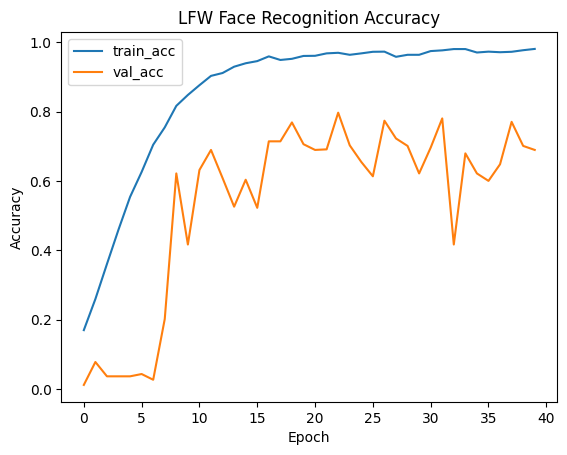

In [8]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LFW Face Recognition Accuracy')
plt.legend()
plt.show()

## Step 9: Visualize Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step


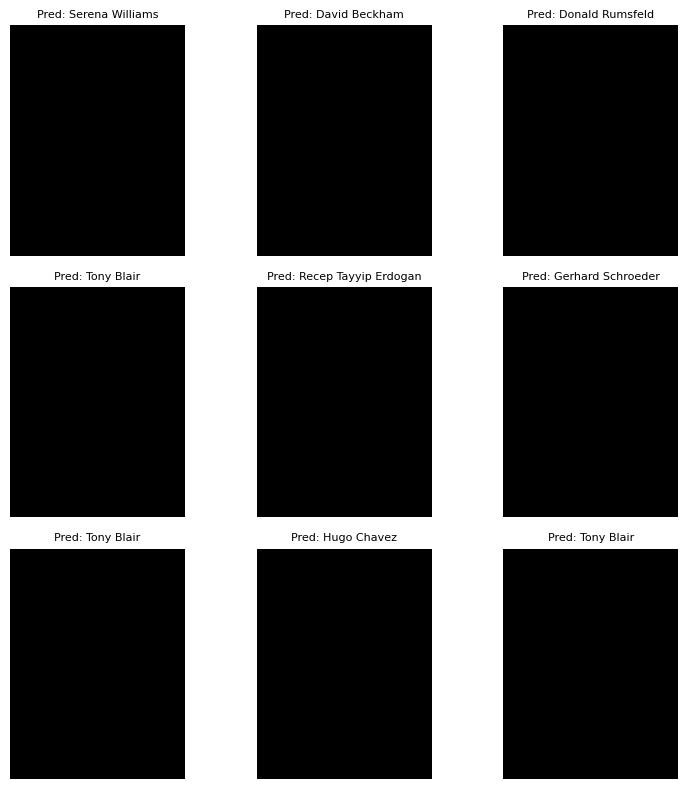

In [9]:
preds = model.predict(X_test[:9])
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(8,8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    ax.set_title(f"Pred: {target_names[pred_labels[i]]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Conclusion

The CNN achieved approximately **81% test accuracy** recognizing faces from the LFW dataset, using 4 convolutional layers with batch normalization and dropout.